# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name:  Stock Success  
Created by Lexinejazly Asuncion (017077242), Pranavi Immanni (017207554), Anika Manjesh (017808479)
Last updated: March 29th, 2026  

# Import Data


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tech
apple_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/apple.csv'
nvidia_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/nvidia.csv'
microsoft_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/microsoft.csv'

# Defense
lockheed_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/lockheedmartin.csv'
northrop_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/northropgrumman.csv'
boeing_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/boeing.csv.zip'

# Waste Management
waste_mgt_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wastemanagementinc.csv'
republic_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/republicservices.csv'
waste_conn_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wasteconnections.csv'



In [2]:
url_list = {
    'AAPL': apple_url,
    'NVDA': nvidia_url,
    'MSFT': microsoft_url,
    'LMT': lockheed_url,
    'NOC': northrop_url,
    'BA': boeing_url,
    'WM': waste_mgt_url,
    'RSG': republic_url,
    'WCN': waste_conn_url
}

for name, url in url_list.items():
    df = pd.read_csv(url)

    print(f"\n{name} Columns:")
    print(df.columns.tolist()) #see list of column names to find common columns


AAPL Columns:
['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

NVDA Columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

MSFT Columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

LMT Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

NOC Columns:
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

BA Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

WM Columns:
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

RSG Columns:
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']

WCN Columns:
['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']


In [3]:
all_frames = []

rename_map = {
    'date': 'Date',
    'price': 'Close',
    'Price': 'Close',
    'Close/Last': 'Close',
    'close': 'Close',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'volume': 'Volume',
    'Vol.': 'Volume',
    'adj_close': 'Adj Close'
}

tech_tickers = ['AAPL', 'NVDA', 'MSFT']
defense_tickers = ['LMT', 'NOC', 'BA']
waste_tickers = ['WM', 'RSG', 'WCN']

#read csv files and store data into one dataframe
for name, url in url_list.items():
    df = pd.read_csv(url,
                     na_values=["-", ""])

    df.columns = [col.strip() for col in df.columns]

    df = df.rename(columns=rename_map)

    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.date

    df['Ticker'] = name

    #create column 'Industry' that specifies the industry
    if name in tech_tickers:
        df['Industry'] = 'Tech'
    elif name in defense_tickers:
        df['Industry'] = 'Defense'
    elif name in waste_tickers:
        df['Industry'] = 'Waste Management'

    #keep only the columns that exist in almost all sets
    standard_cols = ['Industry', 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']
    df = df[standard_cols]

    all_frames.append(df)

#merge the dataframes into one
stocks = pd.concat(all_frames, ignore_index=True)

In [4]:
#clean 'Volume', 'Open', 'High', 'Low', and 'Close' columns
stocks['Volume'] = pd.to_numeric(stocks['Volume'].astype(str).str.replace('M', 'e6').str.replace('K', 'e3').str.replace('B', 'e9'), errors='coerce')

numeric_cols = ['Open', 'High', 'Low', 'Close']

for col in numeric_cols:
    stocks[col] = pd.to_numeric(
        stocks[col].astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')


In [5]:
stocks.head(5)

,Industry,Date,Ticker,Open,High,Low,Close,Volume
0,Tech,2025-09-26,AAPL,254.10,257.60,253.78,255.46,46080000.0
1,Tech,2025-09-25,AAPL,253.21,257.17,251.71,256.87,55200000.0
2,Tech,2025-09-24,AAPL,255.22,255.74,251.04,252.31,42300000.0
3,Tech,2025-09-23,AAPL,255.88,257.34,253.58,254.43,60280000.0
4,Tech,2025-09-22,AAPL,248.30,256.64,248.12,256.08,105520000.0


### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

We cleaned our data in Assignment 1 (P1_relplot-scatter.ipynb) so we no longer have formatting concerns, null values, or inconsistent data. We concatenated the datasets for all stocks into one giant dataframe.

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

**QUESTION**: Which industry exhibits the most consistency with their stocks? How do you know?

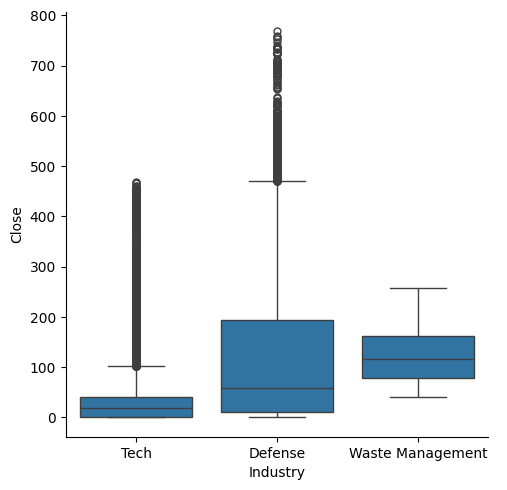

In [6]:
# Your code here . . .
sns.catplot(data=stocks, x='Industry', y='Close', kind='box')
plt.show()

We noticed that the Waste Management Industry exhibits the most consistency with their stock prices. We know this because their box plot is more refined and contains less outliers. While it does not have the smallest Interquartile range, it does contains the most concise range overall which means over the course of the time, the stocks remained more steady relavtive to the Tech and Defense Industry stocks.

### Q3: Come up with a another unique question. This question must use map() or apply()

**QUESTION**: Markets fluctuate a lot every day. Which days are bull markets (increase in value) and which days are bear markets (decrease in value)?

In [7]:
# lowest_value = stocks['Low'].min()
stocks['Market'] = stocks.apply(lambda row: "bull" if (row['Close'] - row['Open']) > 0 else "bear", axis =1)
stocks

,Industry,Date,Ticker,Open,High,Low,Close,Volume,Market
0,Tech,2025-09-26,AAPL,254.1000,257.6000,253.7800,255.4600,46080000.0,bull
1,Tech,2025-09-25,AAPL,253.2100,257.1700,251.7100,256.8700,55200000.0,bull
2,Tech,2025-09-24,AAPL,255.2200,255.7400,251.0400,252.3100,42300000.0,bear
3,Tech,2025-09-23,AAPL,255.8800,257.3400,253.5800,254.4300,60280000.0,bear
4,Tech,2025-09-22,AAPL,248.3000,256.6400,248.1200,256.0800,105520000.0,bull
...,...,...,...,...,...,...,...,...,...
53006,Waste Management,2016-04-01,WCN,42.7276,43.0737,42.6861,43.0460,340707.0,bull
53007,Waste Management,2016-03-31,WCN,42.6722,43.1291,42.6307,42.9630,368628.0,bull
53008,Waste Management,2016-03-30,WCN,43.3368,43.4199,42.5199,42.6168,321878.0,bear
53009,Waste Management,2016-03-29,WCN,42.2707,43.2399,42.2430,43.1845,390691.0,bull


### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

**QUESTION**: Over the years, which industry or industries have shown a pattern of high market volatility?



In [8]:
!pip install hvplot

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import panel as pn
import geopandas
import hvplot.pandas as hvplot
from datetime import datetime
import folium
from panel.interact import interact
pn.extension()
pn.extension('tabulator')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 7.8 MB/s eta 0:00:00


In [9]:
# Need to run pn.extension() to render dashboards
pn.extension("plotly",
             "tabulator")

In [10]:
stocks['Date'] = pd.to_datetime(stocks['Date'])
stocks['Year'] = stocks['Date'].dt.year
stocks['Month'] = stocks['Date'].dt.month

#select years 2016-2024 where all datasets overlap
filtered_stocks = stocks[(stocks['Year'] >= 2016) & (stocks['Year'] <= 2024)]

monthly_stats = filtered_stocks.groupby(['Year', 'Month', 'Industry']).agg(
    Volatility=('Close', 'std'),
    High_Price=('High', 'max'),
    Low_Price=('Low', 'min'),
    Avg_Close=('Close', 'mean'),
    Total_Volume=('Volume', 'sum')
).reset_index()


year_slider = pn.widgets.IntSlider(
    name='Select Year',
    start=filtered_stocks['Year'].min(),
    end=filtered_stocks['Year'].max(),
    value=2024
)

interactive_volatility = monthly_stats.interactive()

stocks_pipeline_plot = interactive_volatility[
    interactive_volatility['Year'] == year_slider
].hvplot(
    x='Month',
    y="Volatility",
    by='Industry',
    line_width=3,
    xlim=(1, 12),
    ylim=(0, (monthly_stats['Volatility'].max()) * 1.1),
    hover_cols=['High_Price', 'Low_Price', 'Avg_Close', 'Total_Volume'],
    title="Monthly Stock Volatility by Industry",
    width=800,
    height=400,
    grid=True
)

stocks_pipeline_plot

According to this interactive plot, the Defense industry has exhibited the highest volatility between 2016 and 2024 between the three industries. This was likely driven by sensitivity to global political events and instability.

The sliders strengthen this idea by allowing the user to dynamically view the data from year to year. Overall, the interactive plot grouped by year and industry allows users to compare market trends over time more easily.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

To strengthen our analysis, we would look for additional datasets that provide more context to our primary data. For example, we could include demographic, geographic, or time-based datasets such as population data, regional information, or historical trends. These additional datasets would help us better understand patterns and relationships within our main dataset.

We would combine datasets using a common key such as a shared column (e.g., date, location, or ID). This could be done using a merge operation in pandas.

In [ ]:
# pseudocode
# combined_df = pd.merge(df_main, df_additional, on="common_column", how="left")

In [ ]:
# If multiple files are involved:
# df_all = pd.concat([df1, df2, df3], ignore_index=True)

Reshaping the data: Some reshaping may be required depending on the structure of the data. This could include converting the dataset from wide to long format, grouping or aggregating values, and handling missing data.

In [ ]:
# Example: wide to long format
# df_long = pd.melt(df, id_vars=["category"], var_name="variable", value_name="value")

# Example: grouping data
 # df_grouped = df.groupby("category").mean().reset_index()

Visualization Sketch: We could create a grouped bar chart or line plot to compare variables across categories or over time. For example, the x-axis could represent categories or time, the y-axis could represent values, and different colors could represent variables from the additional dataset.